In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
# Cargar el dataset
# Reemplaza 'tu_dataset.csv' con el nombre de tu archivo
df = pd.read_csv(r'C:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\ML\datasets\healthcare-dataset-stroke-data.csv')

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
df.head()

Primeras 5 filas del dataset:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
# ================================
# 1. DATA LOADING & INITIAL CHECKS
# ================================

# --- Basic overview ---
print("Shape del dataset:", df.shape)
display(df.head())

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

# --- Missing values ---
print("\nCantidad de valores nulos por columna:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# --- Target distribution ---
print("\nDistribución de la variable objetivo (stroke):")
stroke_counts = df["stroke"].value_counts()
stroke_ratio = df["stroke"].value_counts(normalize=True)

print("Conteo:")
display(stroke_counts)

print("Proporción:")
display(stroke_ratio)

# --- Drop irrelevant columns ---
if "id" in df.columns:
    df = df.drop(columns=["id"])

Shape del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Estadísticas descriptivas:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



Cantidad de valores nulos por columna:


bmi    201
dtype: int64


Distribución de la variable objetivo (stroke):
Conteo:


stroke
0    4861
1     249
Name: count, dtype: int64

Proporción:


stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [4]:
# --- Define features and target ---
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

# --- Train / Validation split ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# --- Split summary ---
print("\nSplit realizado:")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

print("\nDistribución de stroke en train:")
display(y_train.value_counts(normalize=True))

print("\nDistribución de stroke en validation:")
display(y_val.value_counts(normalize=True))


Split realizado:
Train shape: (3577, 10)
Validation shape: (1533, 10)

Distribución de stroke en train:


stroke
0    0.951356
1    0.048644
Name: proportion, dtype: float64


Distribución de stroke en validation:


stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64

In [ ]:
# -------------------
# Split summary
# -------------------
split_summary = pd.DataFrame({
    "set": ["Train", "Validation"],
    "rows": [len(X_train), len(X_val)],
    "stroke_rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_val.mean() * 100, 2)
    ]
})

print("\nSplit summary:")
display(split_summary)

# -------------------
# Visualization (ONLY split)
# -------------------
plt.figure(figsize=(6, 4))

train_val_rates = [y_train.mean() * 100, y_val.mean() * 100]
labels = ["Train", "Validation"]

bars = plt.bar(labels, train_val_rates)

plt.title("Stroke Rate After Stratified Split")
plt.ylabel("Stroke Rate (%)")

# Annotations
for bar, val in zip(bars, train_val_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# -------------------
# Final note
# -------------------
print("\n" + "=" * 60)
print("KEY OBSERVATIONS")
print("=" * 60)
print(f"- Train size: {len(X_train)} | Validation size: {len(X_val)}")
print(f"- Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"- Stroke rate (validation): {y_val.mean()*100:.2f}%")
print("- The stratified split preserves the class distribution across both sets.")

0    3.627004
1         NaN
2    3.511545
3    3.566712
4    3.218876
Name: Log_BMI, dtype: float64

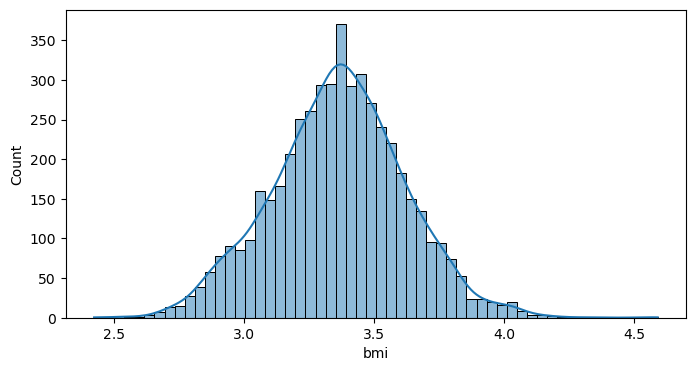

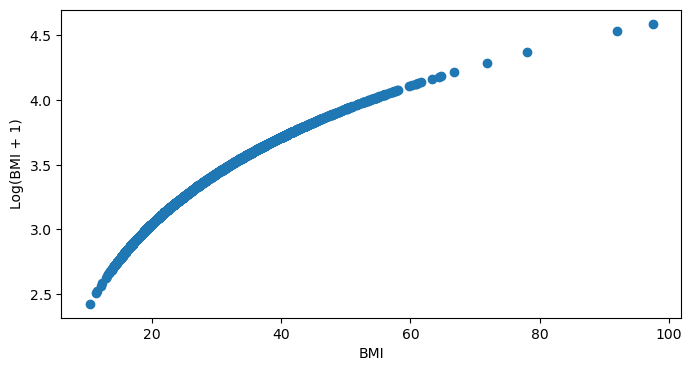

In [ ]:
log = np.log1p(df['bmi'])
plt.figure(figsize=(8, 4))
sns.histplot(log, kde=True)
plt.figure(figsize=(8, 4))
plt.plot(df['bmi'], log, marker='o', linestyle='None')
plt.xlabel('BMI')
plt.ylabel('Log(BMI + 1)')

df['Log_BMI'] = log
df['Log_BMI'].head()

0    5.436731
1    5.314240
2    4.672081
3    5.148831
4    5.165471
Name: Log_avg_glucose_level, dtype: float64

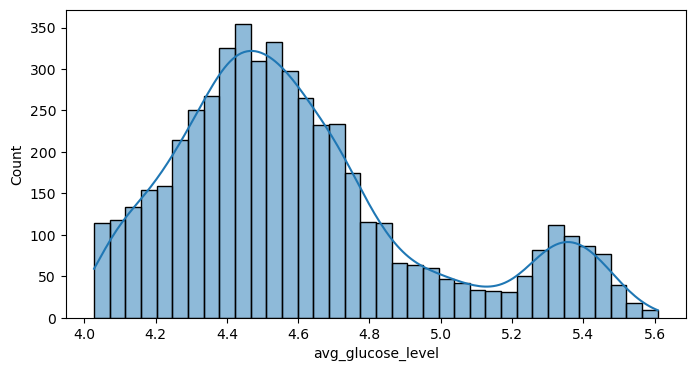

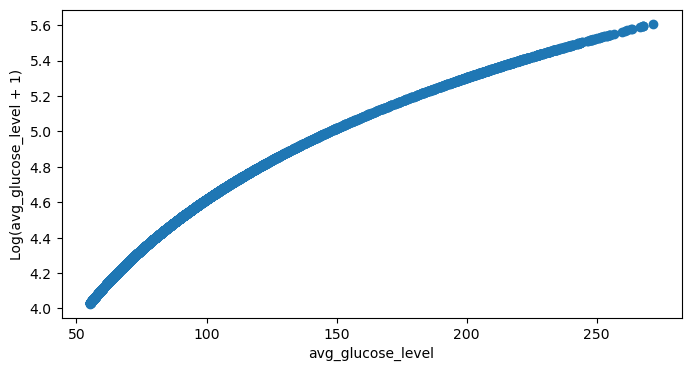

In [ ]:
log = np.log1p(df['avg_glucose_level'])
plt.figure(figsize=(8, 4))
sns.histplot(log, kde=True)
plt.figure(figsize=(8, 4))
plt.plot(df['avg_glucose_level'], log, marker='o', linestyle='None')
plt.xlabel('avg_glucose_level')
plt.ylabel('Log(avg_glucose_level + 1)')

df['Log_avg_glucose_level'] = log
df['Log_avg_glucose_level'].head()

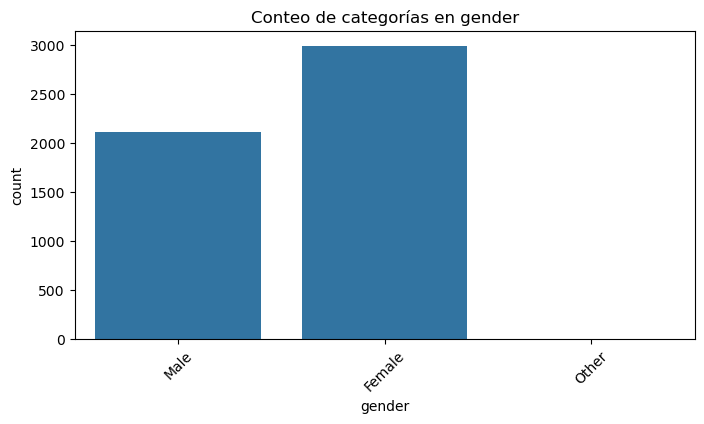

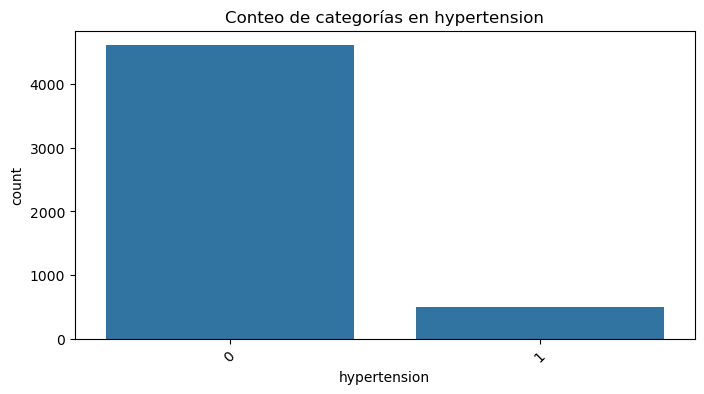

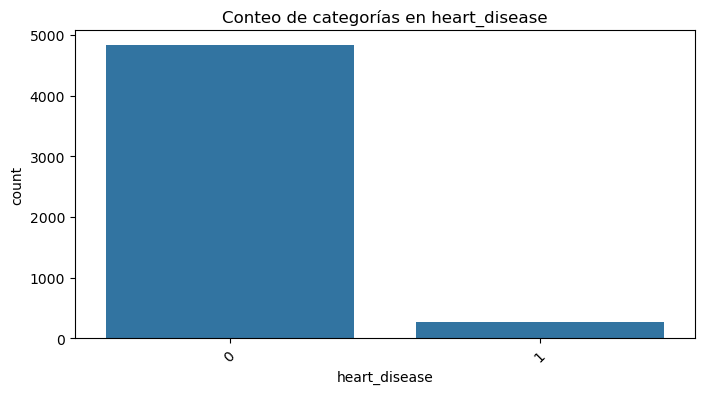

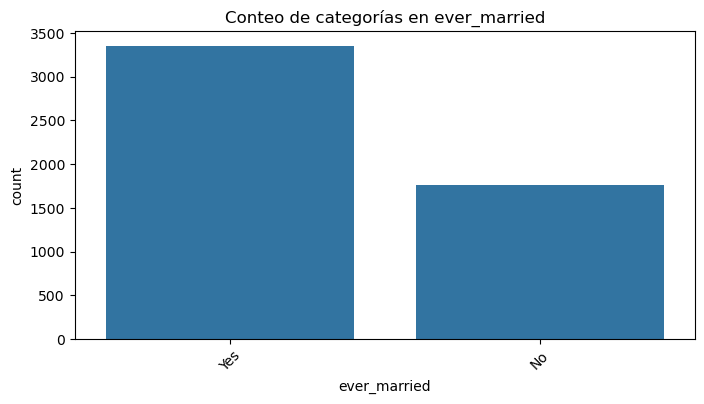

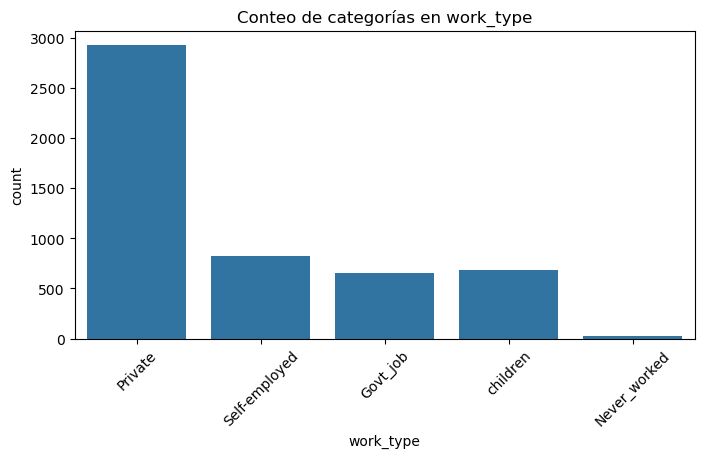

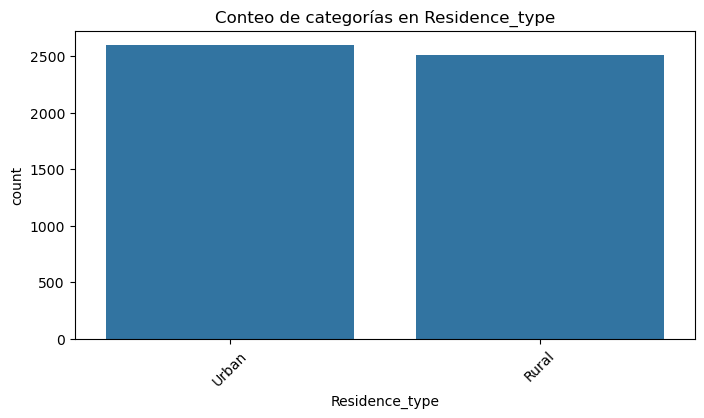

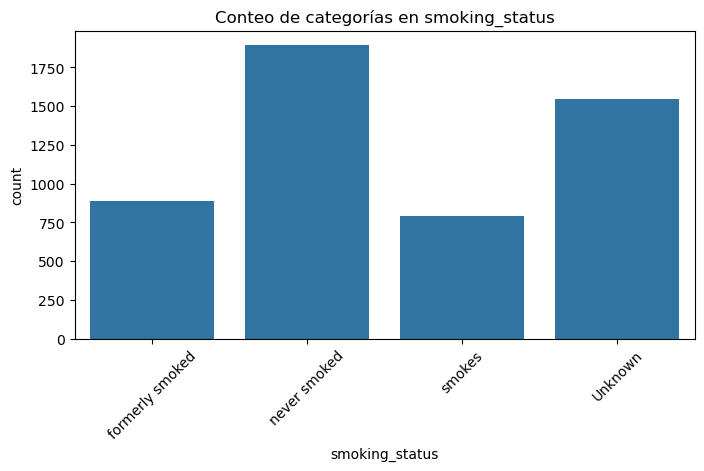

In [ ]:
categoricas = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categoricas:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'Conteo de categorías en {col}')
    plt.xticks(rotation=45)
    plt.show()

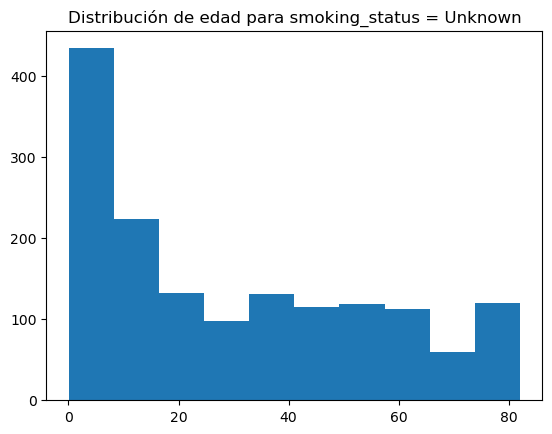

Edad promedio para smoking_status = Unknown: 23.00


In [ ]:
plt.hist(df[df['smoking_status'] == 'Unknown']['age'])
plt.title('Distribución de edad para smoking_status = Unknown')
plt.show()

mean_age_unknown = df[df['smoking_status'] == 'Unknown']['age'].median()
print(f'Edad promedio para smoking_status = Unknown: {mean_age_unknown:.2f}')

(array([  1.,   1.,   0.,   1.,   5.,  12.,  33.,  40.,  45., 111.]),
 array([ 1.32 ,  9.388, 17.456, 25.524, 33.592, 41.66 , 49.728, 57.796,
        65.864, 73.932, 82.   ]),
 <BarContainer object of 10 artists>)

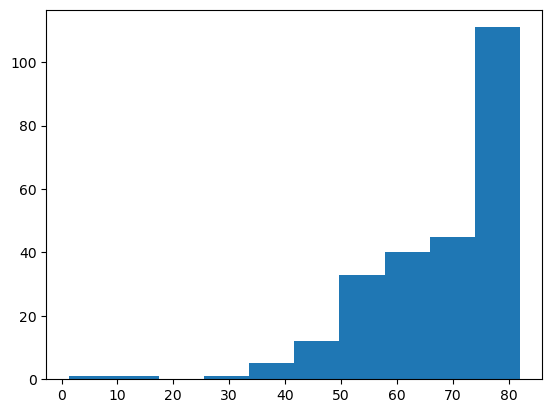

In [ ]:
plt.hist(df[df['stroke'] == 1]['age'])